In [1]:
import pandas as pd
import numpy as np
import torch as t
import torch.nn as nn
import os
import gc
from torch.optim import Adam as Adam
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

### Toy Dataset

In [2]:
file_path = "toy_dataset_2"
os.makedirs('../data/5', exist_ok=True)

n = 70

data = {
    'x_1':       [i for i in range(n)],
    'y_1':       [0] * n,
    'heading_1': [0] * n,

    'x_2':       [i + 10 for i in range(n)],
    'y_2':       [0] * n,
    'heading_2': [0] * n,

    'x_3':       [i + 20 for i in range(n)],
    'y_3':       [0] * n,
    'heading_3': [0] * n,

    'x_4':       [i + 30 for i in range(n)],
    'y_4':       [0] * n,
    'heading_4': [0] * n,

    'x_5':       [i + 40 for i in range(n)],
    'y_5':       [0] * n,
    'heading_5': [0] * n,
}

df = pd.DataFrame(data)

df.to_csv(file_path, index=False)

print(f"Toy CSV created at: {file_path}")
print("Check the file—it should have 7 rows total, with row 4 being empty (NaNs).")

Toy CSV created at: toy_dataset_2
Check the file—it should have 7 rows total, with row 4 being empty (NaNs).


# Data Processing

In [3]:
def distance_to_nearest_neighbour(no_nan_block):

    # checking theres no NaNs in the data
    if no_nan_block.isnull().values.any():
        raise ValueError(f'dataframe contains NaN values {no_nan_block[no_nan_block.isnull().any(axis=1)]}')
    
    # getting the x and y coordinates of fish 1
    x1 = no_nan_block.iloc[:, 0]
    y1 = no_nan_block.iloc[:, 1]

    distances = {}

    # calculating the distnace from fish 1 to each other fish at each time step
    for i in range(2, 6):
        # fish 2 to 5
        dx = no_nan_block.iloc[:, (i-1) * 3] - x1
        dy = no_nan_block.iloc[:, (i-1) * 3 + 1] - y1
        distances[i] = np.sqrt(dx**2 + dy**2)

    # finding the minimum distance across all other fish at each timestep
    distances_df = pd.DataFrame(distances)
    nearest_neighbour_distance = distances_df.min(axis=1)

    return nearest_neighbour_distance.iloc[1:].to_frame(name='nearest_neighbour_disttance')

In [4]:
def relative_angle_to_nearest_neighbour(no_nan_block):

    # checking theres no NaNs in the data
    if no_nan_block.isnull().values.any():
        raise ValueError(f'dataframe contains NaN values {no_nan_block[no_nan_block.isnull().any(axis=1)]}')
    
    # getting the x and y coordinates of fish 1
    x1 = no_nan_block.iloc[:, 0]
    y1 = no_nan_block.iloc[:, 1]
    heading1 = no_nan_block.iloc[:, 2]

    # calculating distance and angle from fish 1 to the other fish at each time step
    distances = {}
    angles = {}
    for i in range(2, 6):
        dx = no_nan_block.iloc[:, (i-1) * 3] - x1
        dy = no_nan_block.iloc[:, (i-1) * 3 + 1] - y1
        distances[i] = np.sqrt(dx**2 + dy**2)
        angles[i] = no_nan_block.iloc[:, (i-1) * 3 + 2] - heading1

    # finding the nearest neighbour at each time step
    distances_df = pd.DataFrame(distances)
    angles_df = pd.DataFrame(angles)
    nearest_neighbour_idx = distances_df.idxmin(axis=1)

    # looking up heading difference corresponding to the nearest neighbour
    relative_angle = pd.Series([angles_df.loc[t, nearest_neighbour_idx[t]] for t in distances_df.index], index=distances_df.index)

    return relative_angle.iloc[1:].to_frame(name='relative_angle_to_nearest_neighbour')

In [5]:
def centre_of_neighbours(positions_array):
    '''
    for each fish at each time step finding the mean
    position for all other visible (not nan) fish - the centre of the nighbours
    '''
    t, n, _ = positions_array.shape # t = timesteps, n = number of fish
    centres = np.full((t, n, 2), np.nan) # pre fill with NaN values so that if the centre cannot be calculated there will still be a NaN value in the array
    n_neighbours = np.zeros((t, n), dtype=int) # creating an empty count array to fill in the loop

    for f in range(n):
        # getting indicies of every fish expect fish f that is the one we are looping over
        otherfish_idx = [j for j in range(n) if j != f]
        otherfish = positions_array[:, otherfish_idx, :] # positions of all other fish

        # finding mean of all neihgbouring fish whilst ignoring the NaN values
        with np.errstate(all='ignore'): # suppressing warnings from all NaN slices
            centres[:, f, :] = np.nanmean(otherfish, axis=1)

        # counting how many neighbours are visible (not NaN) at each timestep
        visible_fish = ~np.isnan(otherfish[:, :, 0])
        n_neighbours[:, f] = visible_fish.sum(axis=1)

    return centres, n_neighbours


In [6]:
def distance_to_group_centroid(no_nan_block):

    # checking theres no NaNs in the data
    if no_nan_block.isnull().values.any():
        raise ValueError(f'dataframe contains NaN values {no_nan_block[no_nan_block.isnull().any(axis=1)]}')
    
    # getting x, y cooridinates for all 5 fish and stacking into an array
    positions = np.stack([no_nan_block.iloc[:, [(i-1)*3, (i-1)*3 + 1]].values for i in range(1, 6)], axis=1)

    # finding centroid - centre of neighbours
    centres, _ = centre_of_neighbours(positions)

    # getting the centroid of neighbours for fish 1 
    fish1_position = positions[:, 0, :]
    fish1_centroid = centres[:, 0, :]

    # calculating distance from fish 1 to the group centroid at each time step
    cohesion_vector = fish1_centroid - fish1_position
    distance = np.linalg.norm(cohesion_vector, axis=1)

    nearest_neighbour_distance = pd.Series(distance, index=no_nan_block.index)

    return nearest_neighbour_distance.iloc[1:].to_frame(name='distance_to_group_centroid')

In [7]:
def relative_angle_to_group_centroid(no_nan_block):

    # checking theres no NaNs in the data
    if no_nan_block.isnull().values.any():
        raise ValueError(f'dataframe contains NaN values {no_nan_block[no_nan_block.isnull().any(axis=1)]}')
    
    # getting x, y cooridinates for all 5 fish and stacking into an array
    positions = np.stack([no_nan_block.iloc[:, [(i-1)*3, (i-1)*3 + 1]].values for i in range(1, 6)], axis=1)

     # finding centroid - centre of neighbours
    centres, _ = centre_of_neighbours(positions)

    # getting fish 1s position, heading and centroid of its neighbours
    fish1_position = positions[:, 0, :]
    fish1_heading = no_nan_block.iloc[:, 2].values
    fish1_centroid = centres[:, 0, :]

    # calculating the angle of the vector from fish 1 to the centroid
    dx = fish1_centroid[:, 0] - fish1_position[:, 0]
    dy = fish1_centroid[:, 1] - fish1_position[:, 1]

    # checking for cases when fish 1 is at the same position as the centroid
    zero_distance = (dx == 0) & (dy == 0)
    if zero_distance.any():
        print(f'Warning: fish 1 is at the same position as the group centroid at timesteps: {no_nan_block.index[zero_distance].tolist()}')

    absolute_angle = np.arctan2(dy, dx)
    absolute_angle[zero_distance] = np.nan  # setting to NaN rather than 0

    # subtracting fish 1s heading to get the relative angle
    relative_angle = absolute_angle - fish1_heading

    relative_angle_series = pd.Series(relative_angle, index=no_nan_block.index)

    return relative_angle_series.iloc[1:].to_frame(name='relative_angle_to_group_centroid')

In [8]:
def relative_angle_to_group_heading(no_nan_block):

    # checking theres no NaNs in the data
    if no_nan_block.isnull().values.any():
        raise ValueError(f'dataframe contains NaN values {no_nan_block[no_nan_block.isnull().any(axis=1)]}')
    
    # gettign fish 1s heading 
    fish1_heading = no_nan_block.iloc[:, 2]

    # getting mean heading of all the other fish 
    other_headings = pd.DataFrame({i: no_nan_block.iloc[:, (i-1)*3 + 2] for i in range(2, 6)})
    mean_group_heading = other_headings.mean(axis=1)

    # finding the relative angle between fish 1s heading the mean of the group heading 
    relative_angle = mean_group_heading - fish1_heading

    relative_angle_series = pd.Series(relative_angle, index=no_nan_block.index)
    
    return relative_angle_series.iloc[1:].to_frame(name='relative_angle_to_group_heading')

In [9]:
def finding_velocity(no_nan_block):
    
    # checking theres no NaNs in the data
    if no_nan_block.isnull().values.any():
        raise ValueError(f'dataframe contains NaN values {no_nan_block[no_nan_block.isnull().any(axis=1)]}')
    
    # getting fish 1s x y coordinates
    x1 = no_nan_block.iloc[:, 0]
    y1 = no_nan_block.iloc[:, 1]

    # calculating the displacement between consecutive timesteps
    dx = x1.diff()
    dy = y1.diff()

    # 2 column data frame
    return pd.DataFrame({'vx_fish1': dx, 'vy_fish1': dy}, index=no_nan_block.index).iloc[1:]

In [10]:
def finding_angular_velocity(no_nan_block):

    # checking theres no NaNs in the data
    if no_nan_block.isnull().values.any():
        raise ValueError(f'dataframe contains NaN values {no_nan_block[no_nan_block.isnull().any(axis=1)]}')
    
    # getting fish 1s heading
    heading1 = no_nan_block.iloc[:, 2]

    # claculating the change in heading between consecutive time steps
    angular_velocity = heading1.diff()

    angular_velocity_series = pd.Series(angular_velocity, index=no_nan_block.index)

    return angular_velocity_series.iloc[1:].to_frame(name='angular_velocity_fish1')

In [11]:
def distance_to_nearest_wall(no_nan_block):

    # checking theres no NaNs in the data
    if no_nan_block.isnull().values.any():
        raise ValueError(f'dataframe contains NaN values {no_nan_block[no_nan_block.isnull().any(axis=1)]}')
    
    # converting wall radius fromcm to mm to match fish coordinates
    inner_radius = 25 * 10
    outer_radius = 35 * 10

    # getting fish 1s x y coordinates
    x1 = no_nan_block.iloc[:, 0]
    y1 = no_nan_block.iloc[:, 1]

    # calculating distnace from fish 1 to centre (0, 0)
    distance_to_centre = np.sqrt(x1**2 + y1**2)

    # claculating distance to each wall
    distance_to_inner_wall = np.abs(distance_to_centre - inner_radius)
    distance_to_outer_wall = np.abs(distance_to_centre - outer_radius)

    # findinf the nearest wall
    nearest_wall_distance = np.minimum(distance_to_inner_wall, distance_to_outer_wall)

    nearest_wall_distance_series = pd.Series(nearest_wall_distance, index=no_nan_block.index)
    return nearest_wall_distance_series.iloc[1:].to_frame(name='distance_to_nearest_wall')

In [12]:
def angle_to_centre(no_nan_block):

    # checking theres no NaNs in the data
    if no_nan_block.isnull().values.any():
        raise ValueError(f'dataframe contains NaN values {no_nan_block[no_nan_block.isnull().any(axis=1)]}')
    
    # getting fish 1s x y coordinates and heading
    x1 = no_nan_block.iloc[:, 0]
    y1 = no_nan_block.iloc[:, 1]
    heading1 = no_nan_block.iloc[:, 2]

    # calculating the angle of vector from fish 1 to centre (0, 0)
    dx = 0 - x1
    dy = 0 - y1
    absolute_angle = np.arctan2(dy, dx)

    # subtracting fish 1a heading to get relative angle
    relative_angle = absolute_angle - heading1

    relative_angle_series = pd.Series(relative_angle, index=no_nan_block.index)

    return relative_angle_series.iloc[1:].to_frame(name='relative_angle_to_centre')

In [13]:
all_training_paths = [
    "data/5/exp05H20140926_10h50.csv",
    "data/5/exp05H20141001_10h05.csv",
    "data/5/exp05H20141003_15h00.csv",
    "data/5/exp05H20141008_15h30.csv",
    "data/5/exp05H20141010_10h38.csv",
    "data/5/exp05H20141015_12h50.csv",
    "data/5/exp05H20141022_11h45.csv",
    "data/5/exp05H20141023_16h20.csv",
    "data/5/exp05H20141029_14h20.csv",
]

In [14]:
feature_functions= [
    finding_velocity,
    finding_angular_velocity,
    distance_to_nearest_neighbour,
    relative_angle_to_nearest_neighbour,
    distance_to_group_centroid,
    relative_angle_to_group_centroid,
    relative_angle_to_group_heading,
    distance_to_nearest_wall,
    angle_to_centre,

]

In [15]:
def split_at_nans_vectorized(data: pd.DataFrame) -> list[pd.DataFrame]:
    """Splits data into contiguous chunks, breaking at any NaN values."""
    
    # 1. Create a boolean mask: True if any NaN exists in the row
    is_nan = data.isna().any(axis=1)
    
    # 2. Create unique group IDs. 
    # The cumulative sum increases by 1 every time it hits a NaN row.
    # This automatically assigns the same integer to contiguous blocks of valid data.
    block_ids = is_nan.cumsum()
    
    # 3. Filter out the actual NaN rows from both the data and the IDs
    valid_data = data[~is_nan]
    valid_block_ids = block_ids[~is_nan]
    
    # 4. Group by the IDs and extract the DataFrames as a list
    data_blocks = [group for _, group in valid_data.groupby(valid_block_ids)]
    
    return data_blocks

In [16]:
def create_sequences(data: np.ndarray, window_size = 30 ) -> tuple[np.ndarray, np.ndarray]:

    shape = data.shape

    X = np.zeros((shape[1], shape[0]-window_size, window_size))
    y = np.zeros((shape[1], shape[0]-window_size))

    for c in range(shape[1]):

        for i in range(len(data) - window_size):

            X[c,i] = data[i : i + window_size, c]
            
            y[c,i] = data[i + window_size, c]

    X = X.transpose(1, 2, 0)
    
    y = y.transpose(1, 0)

    return X, y

In [17]:
def fit_scaler(training_paths: list[str], feature_functions: list) -> StandardScaler:
    scaler = StandardScaler()

    file_dfs = []

    for path in training_paths:

        raw_file_pd = pd.read_csv(f'../{path}')

        nan_free_blocks = split_at_nans_vectorized(raw_file_pd)

        for block in nan_free_blocks:
            block_dfs = []

            for function in feature_functions:
                    
                block_dfs.append(function(block))

            block_attribute_df = pd.concat(block_dfs, axis = 1)

            file_dfs.append(block_attribute_df)

    attribute_df = pd.concat(file_dfs, axis = 0)

    scaler = scaler.fit(attribute_df)

    return scaler

In [27]:
def create_training_sequences(training_paths: pd.Series, feature_functions: list, scaler: StandardScaler, window_size: int = 30) -> tuple[np.ndarray, np.ndarray]:
    all_X = []
    all_y = []
    
    for path in training_paths:
        raw_file_pd = pd.read_csv(f'../{path}')

        nan_free_blocks = split_at_nans_vectorized(raw_file_pd)

        for block in nan_free_blocks:
            block_dfs = [function(block) for function in feature_functions]

            block_attribute_df = pd.concat(block_dfs, axis=1)
            
            attribute_np = block_attribute_df.to_numpy()
            
            if len(attribute_np) <= window_size:
                continue

            attribute_np_scaled = scaler.transform(attribute_np)

            X_seq, y_seq = create_sequences(attribute_np_scaled, window_size=window_size)

            all_X.append(X_seq)
            all_y.append(y_seq)

    if not all_X:
        return np.array([]), np.array([])

    final_X = np.concatenate(all_X, axis=0)
    final_y = np.concatenate(all_y, axis=0)

    return final_X, final_y

In [19]:
def sequences_to_train_val(attribute_np_sequences:tuple[np.ndarray, np.ndarray]) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x, y = attribute_np_sequences

    y = y[:,:3] #Only predicting vx, vy and av

    X_train, X_val, y_train, y_val = train_test_split(
        x, y,
        test_size=0.2,
        random_state=42
    )

    X_train = X_train.astype('float32')
    y_train = y_train.astype('float32')
    X_val = X_val.astype('float32')
    y_val = y_val.astype('float32')

    return X_train, X_val, y_train, y_val

In [20]:
def data_pipeline(training_paths: list[str], feature_functions: list,  window_size: int = 30)  -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    
    scaler = fit_scaler(training_paths, feature_functions)

    training_sequences = create_training_sequences(training_paths, feature_functions, scaler)

    X_train, X_val, y_train, y_val = sequences_to_train_val(training_sequences)

    print(f"X_train shape: {X_train.shape}, type : {type(X_train)}")
    print(f"y_train shape: {y_train.shape}, type : {type(y_train)}")
    print(f"X_val shape: {X_val.shape}, type : {type(X_val)}")
    print(f"y_val shape: {y_val.shape}, type : {type(y_val)}")
    print(f"X_train has NaNs: {np.isnan(X_val).any()}")
    print(f"y_train has NaNs: {np.isnan(y_train).any()}")

    return X_train, X_val, y_train, y_val, scaler
    

In [21]:
X_train, X_val, Y_train, Y_val, scaler = data_pipeline(all_training_paths, feature_functions)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/

X_train shape: (1133050, 30, 10), type : <class 'numpy.ndarray'>
y_train shape: (1133050, 3), type : <class 'numpy.ndarray'>
X_val shape: (283263, 30, 10), type : <class 'numpy.ndarray'>
y_val shape: (283263, 3), type : <class 'numpy.ndarray'>
X_train has NaNs: False
y_train has NaNs: False


# Model

In [22]:
class MyLSTMNet(nn.Module):
    def __init__(self, input_features, hidden_size, out_features):
        super().__init__()
        # batch_first=True tells PyTorch your shape is (batch, seq, feature)
        self.lstm = nn.LSTM(
            input_size=input_features, 
            hidden_size=hidden_size, 
            num_layers=3,
            dropout=0.2,
            batch_first=True 
        )
        self.dropout = nn.Dropout(p=0.2) #Regularization (reduce overfitting)
        
        self.fc = nn.Linear(hidden_size, out_features) #The Output Layer

    def forward(self, x):
        
        # The LSTM outputs two things:
        # lstm_out: The hidden states for ALL 30 time steps
        # (hn, cn): The final hidden and cell states at the very end
        lstm_out, (hn, cn) = self.lstm(x)

        # [:, -1, :] means -> [all batches, the last time step, all hidden features]
        last_time_step = lstm_out[:, -1, :] 
        
        # Apply dropout and pass through the final linear layer
        out = self.dropout(last_time_step)

        predictions = self.fc(out)
        
        return predictions

In [23]:
class FishSequenceDataset(Dataset):
    def __init__(self, X_data, y_data):
        # Store the raw NumPy arrays directly. 
        # No massive upfront tensor conversions!
        self.X = X_data
        self.y = y_data

    def __len__(self):
        # PyTorch needs to know the total number of sequences to calculate epochs
        return len(self.X)

    def __getitem__(self, idx):
        # This is called internally by the DataLoader.
        # We convert to PyTorch tensors piece-by-piece.
        x_seq = t.tensor(self.X[idx], dtype=t.float32)
        y_target = t.tensor(self.y[idx], dtype=t.float32)
        
        return x_seq, y_target

## Training Loop

In [26]:
checkpoint_path = 'ABM_model_3_512.pth'

gc.collect()

device = t.device("mps" if t.backends.mps.is_available() else "cpu")

model = MyLSTMNet(input_features=10, hidden_size=512, out_features=3)

model = model.to(device)

epochs = 200
batch_size = 32

optim = t.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
loss_func = t.nn.MSELoss()

train_set = FishSequenceDataset(X_train, Y_train)
val_set = FishSequenceDataset(X_val, Y_val)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

start_epoch = 0
best_val_loss = float('inf')

if os.path.exists(checkpoint_path):
    checkpoint = t.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optim.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    print(f"--- Resuming training from Epoch {start_epoch} ---")

for epoch in range(start_epoch, epochs): 
    model.train()
    total_train_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        
        optim.zero_grad()

        y_pred = model(x)

        train_loss = loss_func(y_pred,y)

        total_train_loss += train_loss.item()

        train_loss.backward()
        
        optim.step()

    if epoch % 3 == 0:
        total_val_loss = 0
        model.eval()

        with t.no_grad():
            for x_val, y_val in val_loader:
                x_val = x_val.to(device)
                y_val = y_val.to(device)

                y_val_pred = model(x_val)

                val_loss = loss_func(y_val_pred, y_val)

                total_val_loss += val_loss.item()

        avg_train_loss = total_train_loss/len(train_loader)
        avg_val_loss = total_val_loss/len(val_loader)

        print(f"Epoch {epoch}: Avg Train Loss: {avg_train_loss:.4f} | Avg Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            t.save(model.state_dict(), "best_ABM_3_512_model.pth")
            print(f"New best model saved at epoch {epoch}")

    t.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optim.state_dict(),
        'best_val_loss': best_val_loss,
    }, checkpoint_path)
    
    print(f"Epoch {epoch} complete. Checkpoint saved.")

--- Resuming training from Epoch 41 ---
Epoch 41 complete. Checkpoint saved.
Epoch 42: Avg Train Loss: 0.1476 | Avg Val Loss: 0.1451
Epoch 42 complete. Checkpoint saved.


KeyboardInterrupt: 

## Model Results 

optim = t.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

model = MyLSTMNet(input_features=10, hidden_size=256, out_features=3), 2 hidden layers

Epoch 0: Avg Train Loss: 0.1788 | Avg Val Loss: 0.1583

Epoch 3: Avg Train Loss: 0.1554 | Avg Val Loss: 0.1427

Epoch 6: Avg Train Loss: 0.1530 | Avg Val Loss: 0.1421

Epoch 9: Avg Train Loss: 0.1509 | Avg Val Loss: 0.1421

# Testing Model

#### test file
data/5/exp05H20141030_11h15.csv

In [32]:
device = t.device("mps" if t.backends.mps.is_available() else "cpu")
model = MyLSTMNet(input_features=10, hidden_size=256, out_features=3)
test_path = "data/5/exp05H20141030_11h15.csv"
model_weight_path = "Move Prediction/best_ABM_model.pth"
feature_functions = feature_functions
scaler = fit_scaler(all_training_paths, feature_functions)

In [38]:
def predict_fish_path(test_path, model_weight_path, model, target_range, feature_functions, scaler, device, window_size=30):
    start, end = target_range

    full_data = pd.read_csv(f'../{test_path}')
    test_data = full_data.iloc[start:end].copy().reset_index(drop=True)

    real_data = test_data.copy()

    checkpoint = t.load(f"../{model_weight_path}", map_location=device)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()

    vx_mean, vx_scale = scaler.mean_[0], scaler.scale_[0]
    vy_mean, vy_scale = scaler.mean_[1], scaler.scale_[1]
    av_mean, av_scale = scaler.mean_[2], scaler.scale_[2]

    for i in range(len(test_data) - window_size):

        current_window = test_data.iloc[i : i + window_size]

        attribute_list = [func(current_window) for func in feature_functions]
        attribute_df = pd.concat(attribute_list, axis=1)

        scaled_features = scaler.transform(attribute_df)
        input_tensor = t.tensor(scaled_features).float().to(device).unsqueeze(0)

        with t.no_grad():
            predictions = model(input_tensor) 

            vx = predictions[0, 0].item()
            vy = predictions[0, 1].item()
            av = predictions[0, 2].item()

        vx_true = (vx * vx_scale) + vx_mean
        vy_true = (vy * vy_scale) + vy_mean
        av_true = (av * av_scale) + av_mean

        target_idx = i + window_size

        test_data.iloc[target_idx, 0] = test_data.iloc[target_idx - 1, 0] + vx_true
        test_data.iloc[target_idx, 1] = test_data.iloc[target_idx - 1, 1] + vy_true
        test_data.iloc[target_idx, 2] = test_data.iloc[target_idx - 1, 2] + av_true
        
    return real_data, test_data

target_range = (60000,60150)
real_data, prediction_data = predict_fish_path(test_path, model_weight_path, model, target_range, feature_functions, scaler, device)

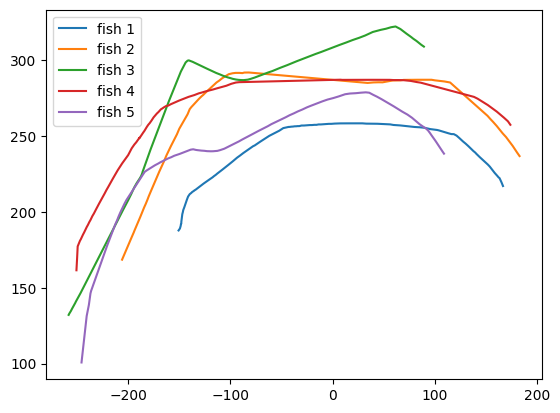

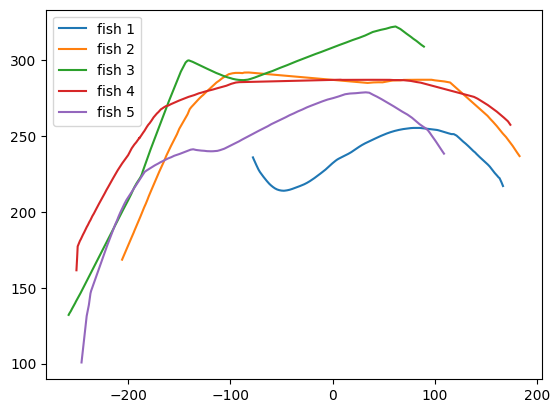

In [39]:
def plot_fish_paths(experement:pd.DataFrame) -> None :
    n_fish = experement.shape[1]//3

    for i in range(0,n_fish*3,3) :
        plt.plot(experement.iloc[:,i],experement.iloc[:,i+1],label=f'fish {1 + i//3}')

    plt.legend()
    plt.show('plots/paths.pdf')

plot_fish_paths(real_data)
plot_fish_paths(prediction_data)
